<a href="https://colab.research.google.com/github/shubha0010/India_Economy_vs_Stock_Market/blob/main/India_Economy_vs_Stock_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why India's Economy Grows While Its Stock Market Falls

Prepared by: **SHUBHA HALDER**,

**Question:** India's GDP is growing fast, yet the Nifty is down about 14% from its peak. Can data explain this?

**Plan**
1. Part A: Load the key figures from the source sheet and chart them.
2. Part B: Show how a few heavyweight stocks can drag an index (contribution analysis).
3. Part C: Pull live market data and measure drawdowns and the Nifty vs. non-Nifty growth stocks.
4. Part D: Test statistically whether GDP growth and market returns move together.
5. Conclusion.

*Figures in Part A and B come from "Stock Market vs Economy" by The Valuation School. Parts C and D fetch live data, so results depend on the day you run them.*

In [1]:
# Setup (Colab already has most of these)
!pip -q install yfinance
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": .3})
print("Ready")

Ready


## Part A: The facts from the source sheet

,Metric,Value
0,"India GDP growth, last quarter (%)",7.8
1,RBI forecast (%),7.0
2,Nifty from peak (%),-14.0
3,Sensex from peak (%),-15.0
4,"Bank Nifty, this year (%)",-10.0
5,"Nifty IT, this year (%)",-27.0
6,Dixon return (%),34.0
7,Amber return (%),21.0


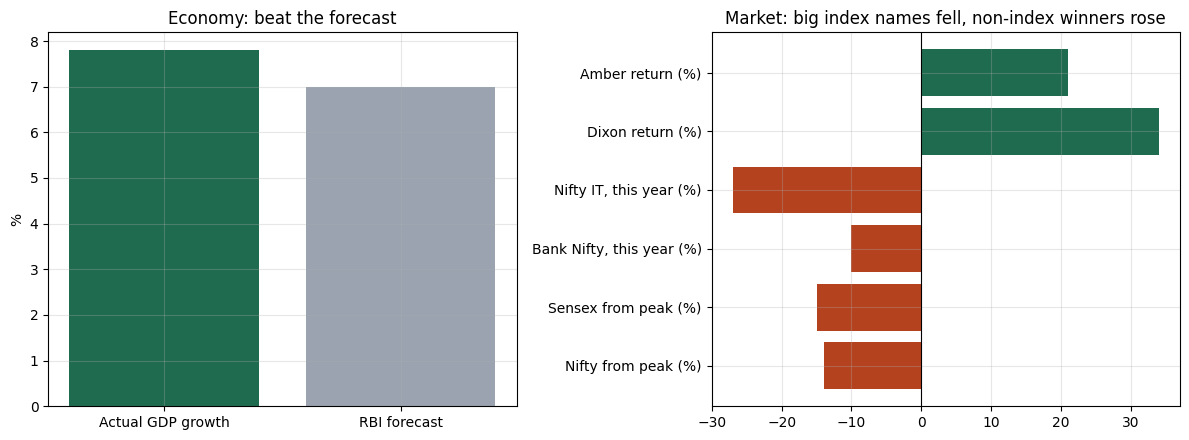

In [2]:
facts = pd.DataFrame({
    "Metric": ["India GDP growth, last quarter (%)", "RBI forecast (%)",
               "Nifty from peak (%)", "Sensex from peak (%)",
               "Bank Nifty, this year (%)", "Nifty IT, this year (%)",
               "Dixon return (%)", "Amber return (%)"],
    "Value":  [7.8, 7.0, -14, -15, -10, -27, 34, 21]})
display(facts)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(["Actual GDP growth", "RBI forecast"], [7.8, 7.0], color=["#1f6b4f", "#9aa3af"])
ax[0].set_title("Economy: beat the forecast"); ax[0].set_ylabel("%")
r = facts.iloc[2:]
ax[1].barh(r["Metric"], r["Value"], color=["#b4421f" if v < 0 else "#1f6b4f" for v in r["Value"]])
ax[1].set_title("Market: big index names fell, non-index winners rose"); ax[1].axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

## Part B: How a few heavyweights drag an index
An index return is the **weighted sum** of its stocks' returns: `contribution = weight x return`.

The sheet says HDFC Bank, ICICI Bank and Reliance are about 27% of the Nifty, and HDFC Bank and Reliance are each down 25%+. It does not give each stock's exact weight or ICICI's return, so the values below are **editable assumptions**. Change them and see how the answer moves.

,Stock,Weight,Return,Contribution (pts)
0,HDFC Bank,11.0,-25.0,-2.75
1,Reliance,9.0,-25.0,-2.25
2,ICICI Bank,7.0,-5.0,-0.35


Top 3 stocks (27% of index) explain about -5.3 percentage points of index change.
That is 38% of the Nifty's ~14% fall, from just 3 stocks.


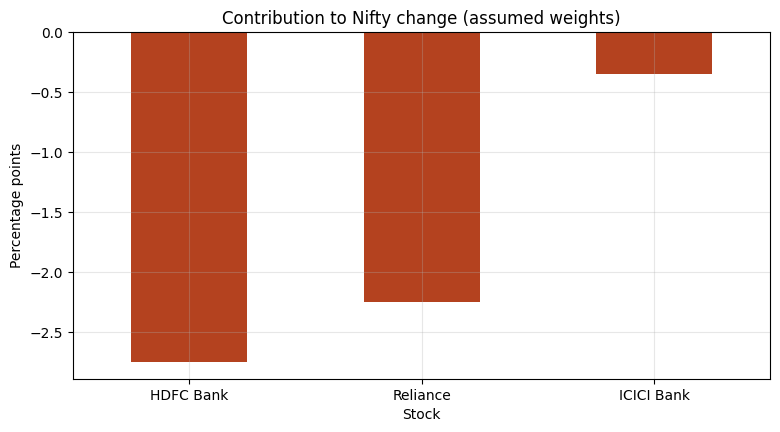

In [3]:
# EDIT THESE ASSUMPTIONS (weights in %, returns in %). Total top-3 weight is ~27% per the source.
top3 = pd.DataFrame({
    "Stock":  ["HDFC Bank", "Reliance", "ICICI Bank"],
    "Weight": [11.0, 9.0, 7.0],      # assumption, sums to 27
    "Return": [-25.0, -25.0, -5.0],  # first two from source (25%+), ICICI assumed
})
top3["Contribution (pts)"] = top3["Weight"] * top3["Return"] / 100
total = top3["Contribution (pts)"].sum()
display(top3)
print(f"Top 3 stocks ({top3.Weight.sum():.0f}% of index) explain about {total:.1f} percentage points of index change.")
print(f"That is {total/-14*100:.0f}% of the Nifty's ~14% fall, from just 3 stocks.")

ax = top3.set_index("Stock")["Contribution (pts)"].plot.bar(color="#b4421f", title="Contribution to Nifty change (assumed weights)")
ax.set_ylabel("Percentage points"); plt.xticks(rotation=0); plt.show()

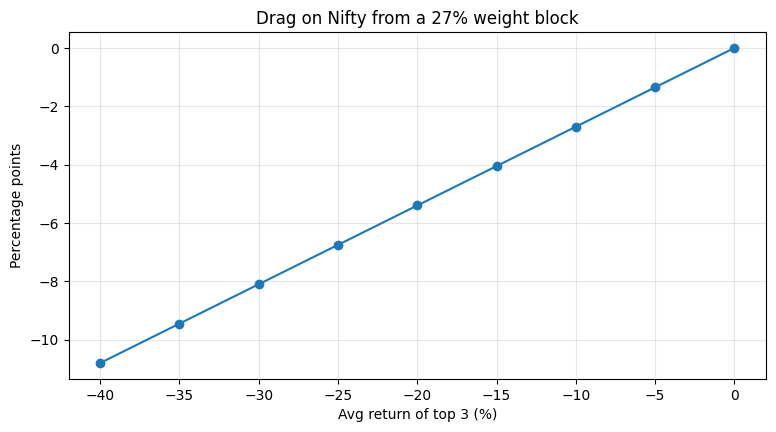

In [4]:
# Sensitivity: how much does the drag depend on the assumed average return of the top 3?
w = 27
rets = np.arange(0, -41, -5)
pd.DataFrame({"Avg return of top 3 (%)": rets, "Drag on Nifty (pts)": w*rets/100}).set_index("Avg return of top 3 (%)").plot(
    legend=False, marker="o", title="Drag on Nifty from a 27% weight block", ylabel="Percentage points"); plt.show()

## Part C: Live market data
We compare the Nifty with Indian stocks **outside** the index's largest names, and measure each series' fall from its peak.

In [5]:
tickers = {"Nifty 50": "^NSEI", "Sensex": "^BSESN", "Bank Nifty": "^NSEBANK", "Nifty IT": "^CNXIT",
           "HDFC Bank": "HDFCBANK.NS", "Reliance": "RELIANCE.NS", "ICICI Bank": "ICICIBANK.NS",
           "Dixon": "DIXON.NS", "Amber": "AMBER.NS", "S&P 500": "^GSPC"}
raw = yf.download(list(tickers.values()), period="2y", auto_adjust=True, progress=False)["Close"]
px = raw.rename(columns={v: k for k, v in tickers.items()}).ffill().dropna(how="all")
print(px.tail(3).round(1))

Ticker       Amber    Dixon  HDFC Bank  ICICI Bank  Reliance   Sensex  \
Date                                                                    
2026-09-28  6990.0  13640.0      719.0      1302.0    1197.6  72771.7   
2026-09-29  6606.5  13250.0      722.7      1292.2    1182.0  72529.1   
2026-09-30  6606.5  13250.0      722.7      1292.2    1182.0  72529.1   

Ticker      Nifty IT  S&P 500  Bank Nifty  Nifty 50  
Date                                                 
2026-09-28   28086.5   7683.7     54471.6   22780.2  
2026-09-29   27670.0   7670.8     54259.9   22716.2  
2026-09-30   27670.0   7651.5     54259.9   22716.2  


,Now vs peak (%)
Ticker,
Nifty IT,-39.8
Dixon,-30.0
HDFC Bank,-27.5
Reliance,-25.4
Amber,-25.3
Sensex,-15.4
Nifty 50,-13.7
Bank Nifty,-11.8
ICICI Bank,-11.8


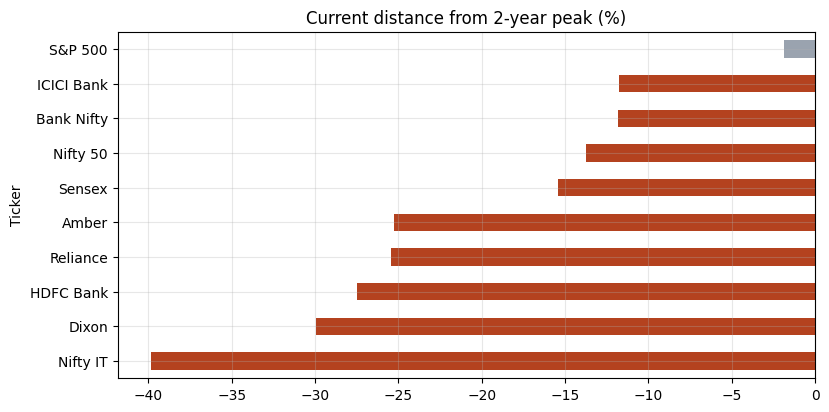

In [6]:
# Drawdown from the running peak
dd = (px / px.cummax() - 1) * 100
latest = dd.iloc[-1].sort_values()
display(latest.round(1).to_frame("Now vs peak (%)"))
latest.plot.barh(color=["#b4421f" if v < -10 else "#9aa3af" for v in latest], title="Current distance from 2-year peak (%)")
plt.show()

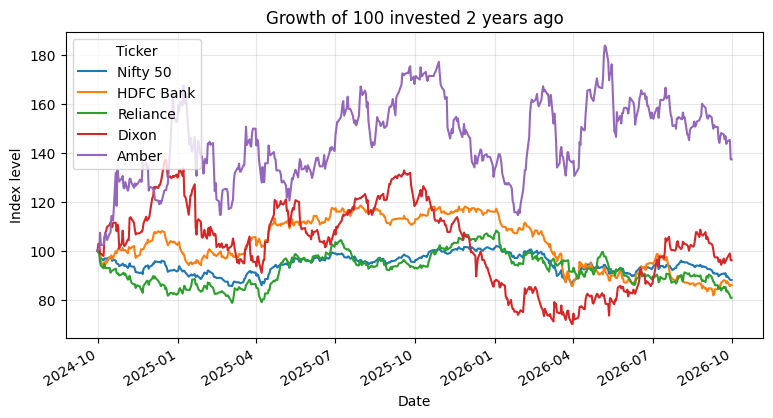

In [7]:
# Normalised growth (start = 100): index vs. manufacturing winners vs. heavyweights
norm = px / px.bfill().iloc[0] * 100
norm[["Nifty 50", "HDFC Bank", "Reliance", "Dixon", "Amber"]].plot(title="Growth of 100 invested 2 years ago")
plt.ylabel("Index level"); plt.show()

## Part D: Do GDP growth and market returns move together?
We pull India's annual real GDP growth from the World Bank and compare it with Nifty calendar-year returns. If the economy drove the market one-for-one, the correlation would be strongly positive.

In [8]:
import requests
url = "https://api.worldbank.org/v2/country/IND/indicator/NY.GDP.MKTP.KD.ZG?format=json&per_page=60"
data = requests.get(url, timeout=30).json()[1]
gdp = pd.Series({int(d["date"]): d["value"] for d in data if d["value"] is not None}).sort_index()

nifty = yf.download("^NSEI", start="2008-01-01", auto_adjust=True, progress=False)["Close"].squeeze()
yr = nifty.resample("YE").last()
ret = (yr.pct_change() * 100).dropna()
ret.index = ret.index.year

df = pd.concat({"GDP growth (%)": gdp, "Nifty return (%)": ret}, axis=1).dropna()
display(df.round(1))
corr = df.corr().iloc[0, 1]
print(f"Correlation between GDP growth and Nifty return: {corr:.2f} (n = {len(df)} years)")

,GDP growth (%),Nifty return (%)
2009,7.9,75.8
2010,8.5,17.9
2011,5.2,-24.6
2012,5.5,27.7
2013,6.4,6.8
2014,7.4,31.4
2015,8.0,-4.1
2016,8.3,3.0
2017,6.8,28.6
2018,6.5,3.2


Correlation between GDP growth and Nifty return: 0.10 (n = 17 years)


R-squared = 0.01: GDP growth explains about 1% of the variation in yearly Nifty returns.
p-value = 0.69


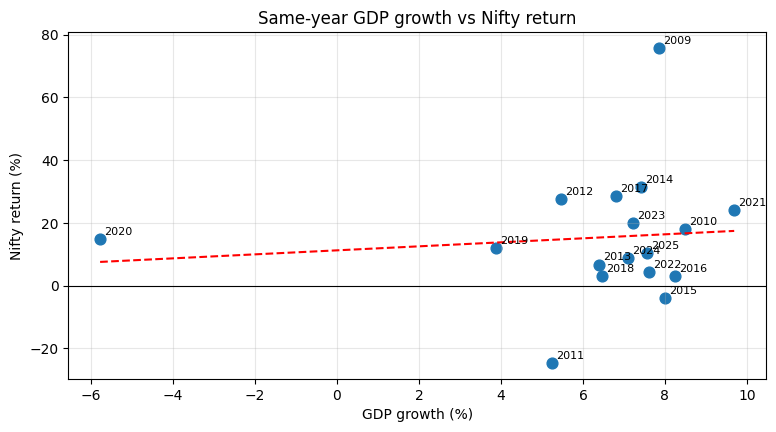

In [9]:
from scipy import stats
slope, intercept, r, p, se = stats.linregress(df["GDP growth (%)"], df["Nifty return (%)"])
print(f"R-squared = {r**2:.2f}: GDP growth explains about {r**2*100:.0f}% of the variation in yearly Nifty returns.")
print(f"p-value = {p:.2f}")
ax = df.plot.scatter(x="GDP growth (%)", y="Nifty return (%)", s=60)
for y_, row in df.iterrows(): ax.annotate(y_, (row.iloc[0], row.iloc[1]), fontsize=8, xytext=(3, 3), textcoords="offset points")
xs = np.linspace(df.iloc[:, 0].min(), df.iloc[:, 0].max(), 50); ax.plot(xs, intercept + slope*xs, "r--")
ax.axhline(0, color="k", lw=.8); ax.set_title("Same-year GDP growth vs Nifty return"); plt.show()

## Conclusion
- **The economy and the market measure different things.** GDP is backward-looking; prices reflect expected future earnings.
- **Concentration matters.** A block of about 27% of the index falling 20%+ removes several points from the Nifty on its own (Part B).
- **The index misses parts of the growth story.** Manufacturing-linked winners like Dixon and Amber are outside the Nifty (Part C).
- **Statistically, same-year GDP growth is a weak predictor of Nifty returns** (Part D). Check the R-squared printed above for the exact figure on the day you run it.

**Limitations:** Part B uses assumed weights; Part D has few data points and ignores lags (markets may lead GDP); yfinance data can have gaps. This is educational work and not investment advice.

**Sources:** Yahoo Finance via `yfinance`; World Bank Open Data.